Name-Riya choudhary

Subject-Computer vision lab

CUID-CU24250251

**Experiment No. 8**

Application of Optical Flow for Real-Time Object Tracking and Motion Analysis

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import math
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
VIDEO_PATH = "tracking_video.mp4"
FRAME_W = 400
FRAME_H = 300
NUM_FRAMES = 100
FPS = 20
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(
    VIDEO_PATH,
    fourcc,
    FPS,
    (FRAME_W, FRAME_H)
)
for i in range(NUM_FRAMES):

    frame = np.zeros((FRAME_H, FRAME_W, 3), dtype=np.uint8)

    # Moving object
    x = 30 + i * 2
    y = 150

    cv2.rectangle(
        frame,
        (x, y - 20),
        (x + 40, y + 20),
        (0, 255, 255),
        -1
    )

    # Add a cross pattern to create trackable corners
    cv2.line(
        frame,
        (x, y - 20),
        (x + 40, y + 20),
        (0, 0, 0),
        2
    )

    cv2.line(
        frame,
        (x + 40, y - 20),
        (x, y + 20),
        (0, 0, 0),
        2
    )

    writer.write(frame)
writer.release()
print("Synthetic video created successfully!")
print("Number of frames:", NUM_FRAMES)
print("Video FPS:", FPS)

Synthetic video created successfully!
Number of frames: 100
Video FPS: 20


First video frame read successfully!
Frame shape: (300, 400, 3)
Grayscale frame shape: (300, 400)


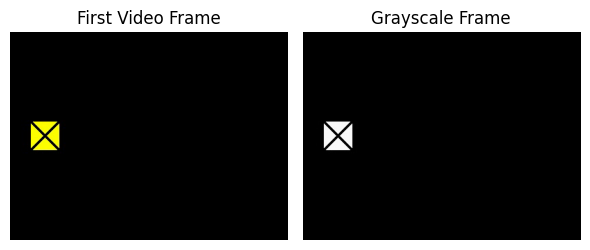

In [11]:
cap = cv2.VideoCapture(VIDEO_PATH)
ret, first_frame = cap.read()
if not ret:
    raise RuntimeError("Could not read the video.")
first_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
print("First video frame read successfully!")
print("Frame shape:", first_frame.shape)
print("Grayscale frame shape:", first_gray.shape)
# Display the first frame and grayscale frame
plt.figure(figsize=(6, 2.5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB))
plt.title("First Video Frame")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(first_gray, cmap="gray")
plt.title("Grayscale Frame")
plt.axis("off")
plt.tight_layout()
plt.show()

Shi-Tomasi Corner Detection completed successfully!
Number of feature points detected: 5


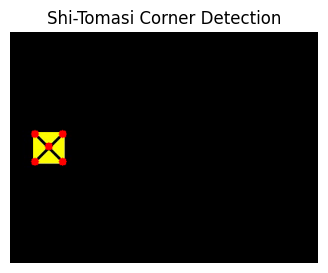

In [12]:
feature_params = dict(
    maxCorners=30,
    qualityLevel=0.2,
    minDistance=5,
    blockSize=7
)
points = cv2.goodFeaturesToTrack(
    first_gray,
    mask=None,
    **feature_params
)
print("Shi-Tomasi Corner Detection completed successfully!")
if points is not None:
    print("Number of feature points detected:", len(points))
else:
    print("No feature points detected.")
# Visualize detected corners
corner_frame = first_frame.copy()
if points is not None:
    for point in points:
        x, y = point.ravel()
        cv2.circle(
            corner_frame,
            (int(x), int(y)),
            5,
            (0, 0, 255),
            -1
        )
plt.figure(figsize=(4, 3))
plt.imshow(cv2.cvtColor(corner_frame, cv2.COLOR_BGR2RGB))
plt.title("Shi-Tomasi Corner Detection")
plt.axis("off")
plt.show()

In [5]:
ret, next_frame = cap.read()
if not ret:
    raise RuntimeError("Could not read the next video frame.")
next_gray = cv2.cvtColor(next_frame, cv2.COLOR_BGR2GRAY)
# Lucas-Kanade parameters
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(
        cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
        10,
        0.03
    )
)
# Calculate optical flow
next_points, status, error = cv2.calcOpticalFlowPyrLK(
    first_gray,
    next_gray,
    points,
    None,
    **lk_params
)
# Select successfully tracked points
good_new = next_points[status == 1]
good_old = points[status == 1]
print("Lucas-Kanade Optical Flow calculated successfully!")
print("Points successfully tracked:", len(good_new))
# Display point movement
for i, (new, old) in enumerate(zip(good_new, good_old)):
    new_x, new_y = new.ravel()
    old_x, old_y = old.ravel()

    print(
        f"Point {i+1}: "
        f"({old_x:.1f}, {old_y:.1f}) -> "
        f"({new_x:.1f}, {new_y:.1f})"
    )

Lucas-Kanade Optical Flow calculated successfully!
Points successfully tracked: 5
Point 1: (50.0, 148.0) -> (52.0, 148.0)
Point 2: (32.0, 168.0) -> (34.0, 168.0)
Point 3: (32.0, 132.0) -> (34.0, 132.0)
Point 4: (68.0, 132.0) -> (70.0, 132.0)
Point 5: (68.0, 168.0) -> (70.0, 168.0)


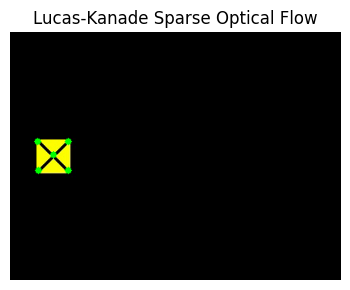

In [13]:
output_lk = next_frame.copy()
for new, old in zip(good_new, good_old):
    new_x, new_y = new.ravel()
    old_x, old_y = old.ravel()

    # Draw motion line
    cv2.line(
        output_lk,
        (int(old_x), int(old_y)),
        (int(new_x), int(new_y)),
        (255, 0, 0),
        2
    )

    # Mark the new position
    cv2.circle(
        output_lk,
        (int(new_x), int(new_y)),
        4,
        (0, 255, 0),
        -1
    )
# Convert BGR to RGB for Matplotlib
output_lk_rgb = cv2.cvtColor(output_lk, cv2.COLOR_BGR2RGB)
# Display output in a smaller size
plt.figure(figsize=(4, 3))
plt.imshow(output_lk_rgb)
plt.title("Lucas-Kanade Sparse Optical Flow")
plt.axis("off")
plt.tight_layout()
plt.show()

In [7]:
cap_fb = cv2.VideoCapture(VIDEO_PATH)
ret, frame1 = cap_fb.read()
ret, frame2 = cap_fb.read()
if not ret:
    raise RuntimeError("Could not read video frames.")
# Convert frames to grayscale
gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
# Calculate Farneback Dense Optical Flow
start_time = time.perf_counter()
flow = cv2.calcOpticalFlowFarneback(
    gray1,
    gray2,
    None,
    0.5,
    3,
    15,
    3,
    5,
    1.2,
    0
)
calculation_time = (time.perf_counter() - start_time) * 1000
print("Farneback Dense Optical Flow calculated successfully!")
print("Flow shape:", flow.shape)
print(f"Calculation time: {calculation_time:.3f} ms")
cap_fb.release()

Farneback Dense Optical Flow calculated successfully!
Flow shape: (300, 400, 2)
Calculation time: 53.950 ms


In [8]:
displacements = good_new - good_old
# Calculate magnitude of motion
magnitude = np.sqrt(
    displacements[:, 0]**2 +
    displacements[:, 1]**2
)
# Calculate direction in degrees
direction = np.degrees(
    np.arctan2(
        displacements[:, 1],
        displacements[:, 0]
    )
)
print("Motion Analysis")
print("----------------")
for i in range(len(good_new)):
    print(
        f"Point {i+1}: "
        f"Displacement = {magnitude[i]:.2f} pixels, "
        f"Direction = {direction[i]:.2f} degrees"
    )
print(f"\nAverage displacement: {np.mean(magnitude):.2f} pixels")
print(f"Maximum displacement: {np.max(magnitude):.2f} pixels")

Motion Analysis
----------------
Point 1: Displacement = 2.00 pixels, Direction = 0.01 degrees
Point 2: Displacement = 2.00 pixels, Direction = -0.02 degrees
Point 3: Displacement = 2.00 pixels, Direction = 0.00 degrees
Point 4: Displacement = 2.00 pixels, Direction = 0.03 degrees
Point 5: Displacement = 2.00 pixels, Direction = -0.02 degrees

Average displacement: 2.00 pixels
Maximum displacement: 2.00 pixels


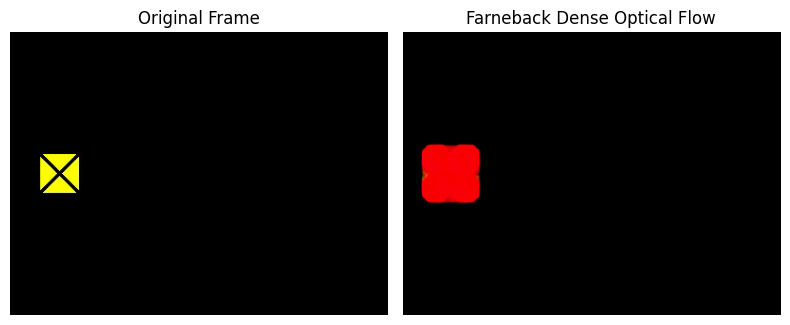

Average flow magnitude: 0.0601
Maximum flow magnitude: 2.0479


In [9]:
flow_magnitude, flow_angle = cv2.cartToPolar(
    flow[..., 0],
    flow[..., 1]
)
# Create HSV image
hsv = np.zeros_like(frame1)
# Set saturation to maximum
hsv[..., 1] = 255
# Direction of motion
hsv[..., 0] = flow_angle * 180 / np.pi / 2
# Magnitude of motion
hsv[..., 2] = cv2.normalize(
    flow_magnitude,
    None,
    0,
    255,
    cv2.NORM_MINMAX
)
# Convert HSV to BGR
dense_flow = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
# Convert BGR to RGB for Matplotlib
dense_flow_rgb = cv2.cvtColor(
    dense_flow,
    cv2.COLOR_BGR2RGB
)
# Display output
plt.figure(figsize=(8, 3.5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB))
plt.title("Original Frame")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(dense_flow_rgb)
plt.title("Farneback Dense Optical Flow")
plt.axis("off")
plt.tight_layout()
plt.show()
print(f"Average flow magnitude: {np.mean(flow_magnitude):.4f}")
print(f"Maximum flow magnitude: {np.max(flow_magnitude):.4f}")

In [10]:
print("Lucas-Kanade vs Farneback Comparison")
print("-------------------------------------")
print(f"{'Property':25s} | {'Lucas-Kanade':20s} | {'Farneback':20s}")
print("-" * 72)
print(f"{'Type':25s} | {'Sparse':20s} | {'Dense':20s}")
print(f"{'Coverage':25s} | {'Selected points':20s} | {'Every pixel':20s}")
print(f"{'Tracked points':25s} | {len(good_new):20d} | {'400 x 300 pixels':20s}")
print(f"{'Time per frame (ms)':25s} | {'N/A':20s} | {calculation_time:20.3f}")
print(f"{'Output':25s} | {'Point trajectories':20s} | {'Dense flow field':20s}")
print(f"{'Best suited for':25s} | {'Object tracking':20s} | {'Motion analysis':20s}")

Lucas-Kanade vs Farneback Comparison
-------------------------------------
Property                  | Lucas-Kanade         | Farneback           
------------------------------------------------------------------------
Type                      | Sparse               | Dense               
Coverage                  | Selected points      | Every pixel         
Tracked points            |                    5 | 400 x 300 pixels    
Time per frame (ms)       | N/A                  |               53.950
Output                    | Point trajectories   | Dense flow field    
Best suited for           | Object tracking      | Motion analysis     
